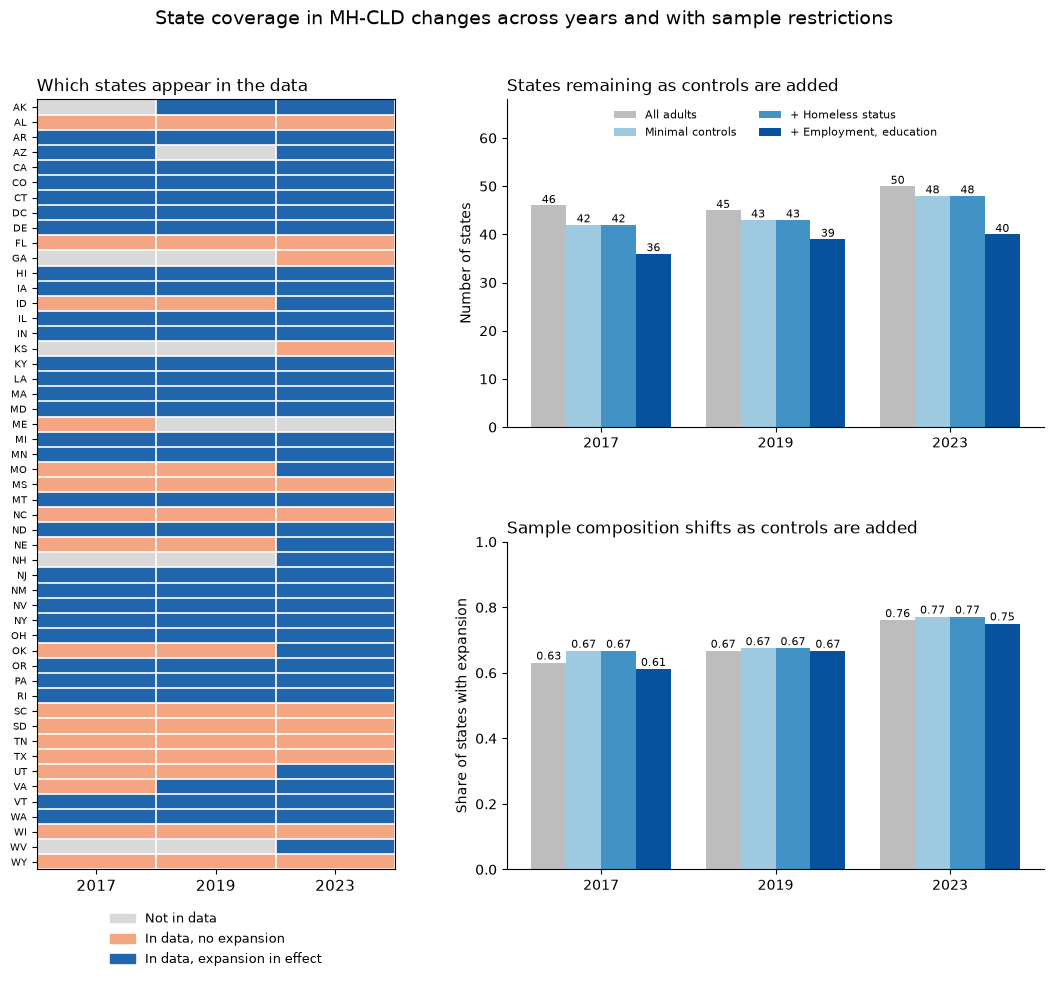

In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

conn = sqlite3.connect("mhcld.db")
os.makedirs("figures", exist_ok=True)

abbr = {1:"AL",2:"AK",4:"AZ",5:"AR",6:"CA",8:"CO",9:"CT",10:"DE",11:"DC",12:"FL",13:"GA",
        15:"HI",16:"ID",17:"IL",18:"IN",19:"IA",20:"KS",21:"KY",22:"LA",23:"ME",24:"MD",
        25:"MA",26:"MI",27:"MN",28:"MS",29:"MO",30:"MT",31:"NE",32:"NV",33:"NH",34:"NJ",
        35:"NM",36:"NY",37:"NC",38:"ND",39:"OH",40:"OK",41:"OR",42:"PA",44:"RI",45:"SC",
        46:"SD",47:"TN",48:"TX",49:"UT",50:"VT",51:"VA",53:"WA",54:"WV",55:"WI",56:"WY"}
YEARS = [2017, 2019, 2023]

MINIMAL = ("adult = 1 AND smi_sed IS NOT NULL AND sud IS NOT NULL AND female IS NOT NULL "
           "AND race IS NOT NULL AND ethnic IS NOT NULL AND age_grp IS NOT NULL")
CORE = MINIMAL + " AND homeless IS NOT NULL"
FULL = CORE + " AND employed IS NOT NULL AND educ IS NOT NULL"

# One pass over the data: records per state-year at each sample tier
cov = pd.read_sql(f"""
SELECT YEAR, STATEFIP, MAX(expansion) AS expansion,
       SUM(CASE WHEN adult = 1 THEN 1 ELSE 0 END) AS adults,
       SUM(CASE WHEN {MINIMAL} THEN 1 ELSE 0 END) AS minimal,
       SUM(CASE WHEN {CORE} THEN 1 ELSE 0 END)    AS core,
       SUM(CASE WHEN {FULL} THEN 1 ELSE 0 END)    AS full_controls
FROM clean_records
WHERE YEAR IN (2017, 2019, 2023)
GROUP BY YEAR, STATEFIP""", conn)

# Grid: 0 = not in data, 1 = in data/no expansion, 2 = in data/expansion in effect
states = sorted(abbr, key=abbr.get)
grid = np.zeros((len(states), len(YEARS)))
for j, y in enumerate(YEARS):
    sub = cov[cov["YEAR"] == y].set_index("STATEFIP")
    for i, s in enumerate(states):
        if s in sub.index:
            grid[i, j] = 2 if sub.loc[s, "expansion"] == 1 else 1

# States retained and expansion share at each sample tier
tiers = [("adults", "All adults"), ("minimal", "Minimal controls"),
         ("core", "+ Homeless status"), ("full_controls", "+ Employment, education")]
n_states, exp_share = {}, {}
for key, _ in tiers:
    for y in YEARS:
        sub = cov[(cov["YEAR"] == y) & (cov[key] > 0)]
        n_states[(key, y)] = len(sub)
        exp_share[(key, y)] = sub["expansion"].mean()

fig = plt.figure(figsize=(13, 10))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 1.5], hspace=0.35, wspace=0.25)

ax = fig.add_subplot(gs[:, 0])
cmap = ListedColormap(["#d9d9d9", "#f4a582", "#2166ac"])
ax.imshow(grid, aspect="auto", cmap=cmap, vmin=0, vmax=2)
ax.set_xticks(range(len(YEARS))); ax.set_xticklabels(YEARS, fontsize=11)
ax.set_yticks(range(len(states))); ax.set_yticklabels([abbr[s] for s in states], fontsize=7)
ax.set_title("Which states appear in the data", fontsize=12, loc="left")
ax.set_xticks(np.arange(-.5, len(YEARS), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(states), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.2); ax.tick_params(which="minor", length=0)
ax.legend(handles=[Patch(color="#d9d9d9", label="Not in data"),
                   Patch(color="#f4a582", label="In data, no expansion"),
                   Patch(color="#2166ac", label="In data, expansion in effect")],
          loc="upper center", bbox_to_anchor=(0.5, -0.04), ncol=1, fontsize=9, frameon=False)

colors = ["#bdbdbd", "#9ecae1", "#4292c6", "#08519c"]
x = np.arange(len(YEARS)); w = 0.2

ax2 = fig.add_subplot(gs[0, 1])
for k, (key, label) in enumerate(tiers):
    vals = [n_states[(key, y)] for y in YEARS]
    bars = ax2.bar(x + (k - 1.5) * w, vals, w, label=label, color=colors[k])
    for b, v in zip(bars, vals):
        ax2.text(b.get_x() + b.get_width() / 2, v + 0.5, str(v), ha="center", fontsize=8)
ax2.set_xticks(x); ax2.set_xticklabels(YEARS)
ax2.set_ylabel("Number of states"); ax2.set_ylim(0, 68)
ax2.set_title("States remaining as controls are added", fontsize=12, loc="left")
ax2.legend(fontsize=8, ncol=2, frameon=False, loc="upper center")
ax2.spines[["top", "right"]].set_visible(False)

ax3 = fig.add_subplot(gs[1, 1])
for k, (key, label) in enumerate(tiers):
    vals = [exp_share[(key, y)] for y in YEARS]
    bars = ax3.bar(x + (k - 1.5) * w, vals, w, color=colors[k])
    for b, v in zip(bars, vals):
        ax3.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
ax3.set_xticks(x); ax3.set_xticklabels(YEARS)
ax3.set_ylabel("Share of states with expansion"); ax3.set_ylim(0, 1)
ax3.set_title("Sample composition shifts as controls are added", fontsize=12, loc="left")
ax3.spines[["top", "right"]].set_visible(False)

fig.suptitle("State coverage in MH-CLD changes across years and with sample restrictions",
             fontsize=14, y=0.97)
plt.savefig("figures/coverage_by_year.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)
YEARS = [2017, 2019, 2023]

# Estimates and state-clustered standard errors copied from the model output
# (adults; outcome = additional diagnoses per client)
est = {
    "minimal": {
        "Expansion only":            ([-0.104, 0.081, 0.102], [0.096, 0.142, 0.200]),
        "+ Division & demographics": ([ 0.097, 0.305, 0.083], [0.107, 0.146, 0.190]),
    },
    "full": {
        "Expansion only":            ([ 0.108, 0.268, 0.252], [0.093, 0.159, 0.247]),
        "+ All controls":            ([ 0.289, 0.380,-0.004], [0.125, 0.174, 0.241]),
    },
}
n_states = {"minimal": [42, 43, 48], "full": [36, 39, 40]}
titles = {"minimal": "Minimal-controls sample", "full": "Full-controls sample (thesis-style)"}
colors = ["#9e9e9e", "#08519c"]
fe_coef, fe_se = 0.0513, 0.1199

fig, axes = plt.subplots(1, 3, figsize=(14, 5.5), sharey=True,
                         gridspec_kw={"width_ratios": [3, 3, 1.1]})

for ax, key in zip(axes[:2], ["minimal", "full"]):
    for k, (label, (coefs, ses)) in enumerate(est[key].items()):
        xs = np.arange(len(YEARS)) + (k - 0.5) * 0.22
        coefs, ses = np.array(coefs), np.array(ses)
        ax.errorbar(xs, coefs, yerr=1.96 * ses, fmt="o", color=colors[k],
                    capsize=4, markersize=7, label=label)
    ax.axhline(0, color="black", linewidth=1, linestyle="--")
    ax.set_xticks(range(len(YEARS)))
    ax.set_xticklabels([f"{y}\n({n} states)" for y, n in zip(YEARS, n_states[key])])
    ax.set_title(titles[key], fontsize=12, loc="left")
    ax.legend(fontsize=9, frameon=False, loc="upper left")
    ax.spines[["top", "right"]].set_visible(False)

ax = axes[2]
ax.errorbar([0], [fe_coef], yerr=[1.96 * fe_se], fmt="s", color="#b2182b", capsize=4, markersize=7)
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_xticks([0]); ax.set_xticklabels(["State + year\nfixed effects\n(6 switching\nstates)"])
ax.set_xlim(-0.6, 0.6)
ax.set_title("Pooled", fontsize=12, loc="left")
ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Effect of expansion on diagnoses per client")
fig.suptitle("Estimated association between Medicaid expansion and diagnoses: no stable pattern across years",
             fontsize=13, y=1.0)
fig.text(0.5, -0.03, "Dots are point estimates; bars are 95% confidence intervals from state-clustered standard errors.",
         ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("figures/effects_by_year.png", dpi=200, bbox_inches="tight")
plt.show()